# Chapitre 5 — Modèles Prédictifs du Spread : Ridge/Lasso → XGBoost
### Mémoire M2 ISF — Modélisation du Spread de Taux

**Version Colab corrigée — aucun fichier local nécessaire**

Ce notebook couvre :
1. Téléchargement et préparation des données
2. Feature engineering enrichi
3. Baseline : Ridge et Lasso
4. XGBoost avec validation temporelle correcte
5. Comparaison des performances
6. Analyse SHAP — drivers économiques par régime

---

## 0. Imports

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'shap', '-q'], capture_output=True)

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('figures', exist_ok=True)

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import shap

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
np.random.seed(42)
print('OK imports')

OK imports


## 1. Téléchargement des données BCE

In [2]:
def fetch_ecb(series_key, name, start='2000-01-01'):
    flow, key = series_key.split('/', 1)
    url = (
        f'https://data-api.ecb.europa.eu/service/data/{flow}/{key}'
        f'?startPeriod={start}&format=csvdata'
    )
    try:
        r = requests.get(url, timeout=30)

        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text))
        df['date'] = pd.to_datetime(df['TIME_PERIOD'])
        df = df.set_index('date').sort_index()
        series = pd.to_numeric(df['OBS_VALUE'], errors='coerce')
        series.name = name
        series = series.resample('ME').last().dropna()
        print(f'  OK {name} : {len(series)} obs')
        return series
    except Exception as e:
        print(f'  ERREUR {name} : {e}')
        return None

print('Telechargement...')
euribor  = fetch_ecb('FM/M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA', 'Euribor_3M')
euribor6 = fetch_ecb('FM/M.U2.EUR.RT.MM.EURIBOR6MD_.HSTA', 'Euribor_6M')
swap_1y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y',  'Swap_1Y')
swap_2y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y',  'Swap_2Y')
swap_5y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y',  'Swap_5Y')
swap_10y = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y', 'Swap_10Y')
print('OK !')

Telechargement...
  OK Euribor_3M : 319 obs
  OK Euribor_6M : 319 obs
  OK Swap_1Y : 264 obs
  OK Swap_2Y : 264 obs
  OK Swap_5Y : 264 obs
  OK Swap_10Y : 264 obs
OK !


## 2. Feature Engineering enrichi

On ajoute des features de momentum (variation sur 6 et 12 mois)
qui capturent l'accélération de la politique monétaire —
crucial pour prédire le spread en période de hausse rapide des taux.

In [3]:
df = pd.DataFrame({
    'Euribor_3M': euribor,
    'Euribor_6M': euribor6,
    'Swap_1Y':    swap_1y,
    'Swap_2Y':    swap_2y,
    'Swap_5Y':    swap_5y,
    'Swap_10Y':   swap_10y,
})
df = df.resample('ME').last().dropna(thresh=4)

feat = pd.DataFrame(index=df.index)

# Variable cible
feat['Spread'] = df['Swap_5Y'] - df['Euribor_3M']

# Facteurs Nelson-Siegel (beta1, beta2, beta3)
feat['Level']     = df['Euribor_3M']
feat['Slope']     = df['Swap_10Y'] - df['Euribor_3M']
feat['Curvature'] = 2*df['Swap_5Y'] - df['Swap_10Y'] - df['Euribor_3M']

# Volatilite rolling
feat['Volatility']     = df['Euribor_3M'].rolling(3).std()

# Variations de taux — momentum a differentes frequences
feat['Delta_Rate_1m']  = df['Euribor_3M'].diff(1)    # variation mensuelle
feat['Delta_Rate_6m']  = df['Euribor_3M'].diff(6)    # variation sur 6 mois
feat['Delta_Rate_12m'] = df['Euribor_3M'].diff(12)   # variation sur 12 mois

# Lags du spread (autoregressivite)
feat['Spread_lag1'] = feat['Spread'].shift(1)
feat['Spread_lag3'] = feat['Spread'].shift(3)
feat['Spread_lag6'] = feat['Spread'].shift(6)

# Spread OIS (prime de liquidite)
feat['OIS_Spread'] = df['Swap_2Y'] - df['Euribor_3M']

# Spread Euribor 6M-3M (prime de terme courte)
feat['Term_spread_short'] = df['Euribor_6M'] - df['Euribor_3M']

feat = feat.dropna()

print(f'Dataset : {feat.shape[0]} obs x {feat.shape[1]} colonnes')
print(f'Periode : {feat.index[0].strftime("%Y-%m")} -> {feat.index[-1].strftime("%Y-%m")}')

Dataset : 251 obs x 13 colonnes
Periode : 2005-09 -> 2026-07


## 3. Préparation ML — Split temporel correct

**Split : Train 2004-2020 | Test 2021-2026**

On inclut 2020 (COVID) dans le train pour que le modèle
ait vu au moins un épisode de stress avant d'être testé.

**Règle fondamentale anti-leakage :**
Le scaler est fitté UNIQUEMENT sur le train,
puis appliqué (transform only) sur le test.

In [4]:
FEATURES = [
    'Level', 'Slope', 'Curvature', 'Volatility',
    'Delta_Rate_1m', 'Delta_Rate_6m', 'Delta_Rate_12m',
    'Spread_lag1', 'Spread_lag3', 'Spread_lag6',
    'OIS_Spread', 'Term_spread_short'
]
TARGET = 'Spread'

X = feat[FEATURES].values
y = feat[TARGET].values
dates = feat.index

# Split 2021 — inclut COVID dans le train
split_date = '2021-01-01'
split_idx  = feat.index.searchsorted(split_date)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train = dates[:split_idx]
dates_test  = dates[split_idx:]

# Normalisation sur train uniquement
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# TimeSeriesSplit pour la cross-validation
tscv = TimeSeriesSplit(n_splits=5)

print(f'Train : {len(X_train)} obs ({dates_train[0].strftime("%Y-%m")} -> {dates_train[-1].strftime("%Y-%m")})')
print(f'Test  : {len(X_test)}  obs ({dates_test[0].strftime("%Y-%m")} -> {dates_test[-1].strftime("%Y-%m")})')
print(f'Features : {len(FEATURES)} variables')

Train : 184 obs (2005-09 -> 2020-12)
Test  : 67  obs (2021-01 -> 2026-07)
Features : 12 variables


## 4. Baseline : Ridge et Lasso

In [5]:
# Cellule 10 (Ridge/Lasso) — dans evaluate_model, remplace :
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<22} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return {'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'y_pred': y_pred}

results = {}

# Ridge
ridge = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=tscv)
ridge.fit(X_train_sc, y_train)
results['Ridge'] = evaluate_model('Ridge', y_test, ridge.predict(X_test_sc))

# Lasso
lasso = LassoCV(alphas=np.logspace(-6, 2, 100), cv=tscv, max_iter=10000)
lasso.fit(X_train_sc, y_train)
results['Lasso'] = evaluate_model('Lasso', y_test, lasso.predict(X_test_sc))

print(f'\nLambda Ridge : {ridge.alpha_:.6f}')
print(f'Lambda Lasso : {lasso.alpha_:.6f}')

print('\nCoefficients Lasso (selection de variables) :')
for fname, coef in zip(FEATURES, lasso.coef_):
    status = 'GARDE' if abs(coef) > 1e-6 else 'elimine'
    print(f'  {fname:<22} : {coef:+.4f}  ({status})')

  Ridge                  RMSE=0.0000  MAE=0.0000  R²=1.0000
  Lasso                  RMSE=0.0003  MAE=0.0002  R²=1.0000

Lambda Ridge : 0.000100
Lambda Lasso : 0.000060

Coefficients Lasso (selection de variables) :
  Level                  : +0.0000  (elimine)
  Slope                  : +0.4513  (GARDE)
  Curvature              : +0.2574  (GARDE)
  Volatility             : +0.0000  (GARDE)
  Delta_Rate_1m          : -0.0000  (GARDE)
  Delta_Rate_6m          : -0.0000  (GARDE)
  Delta_Rate_12m         : -0.0000  (elimine)
  Spread_lag1            : +0.0004  (GARDE)
  Spread_lag3            : +0.0000  (elimine)
  Spread_lag6            : +0.0000  (elimine)
  OIS_Spread             : +0.0004  (GARDE)
  Term_spread_short      : +0.0000  (GARDE)


## 5. XGBoost

In [6]:
val_size  = 12  # réduit à 12 mois au lieu de 24
X_tr      = X_train[:-val_size]
X_val     = X_train[-val_size:]
y_tr      = y_train[:-val_size]
y_val     = y_train[-val_size:]

xgb_model = xgb.XGBRegressor(
    n_estimators          = 1000,
    max_depth             = 3,       # réduit pour éviter overfit sur peu de données
    learning_rate         = 0.01,    # plus lent = plus robuste
    subsample             = 0.9,
    colsample_bytree      = 0.9,
    min_child_weight      = 3,
    reg_alpha             = 0.05,
    reg_lambda            = 1.0,
    random_state          = 42,
    verbosity             = 0,
    early_stopping_rounds = 50       # plus patient
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

results['XGBoost'] = evaluate_model('XGBoost', y_test, xgb_model.predict(X_test))
print(f'Arbres utilises : {xgb_model.best_iteration}')
print(f'Train : {len(X_tr)} obs | Validation : {len(X_val)} obs')

  XGBoost                RMSE=0.2524  MAE=0.1821  R²=0.9052
Arbres utilises : 999
Train : 172 obs | Validation : 12 obs


## 6. Comparaison des performances

  COMPARAISON — TEST 2021-2026
  Modele                       RMSE        MAE       R2
-----------------------------------------------------------------
  Ridge                      0.0000      0.0000   1.0000
  Lasso                      0.0003      0.0002   1.0000
  XGBoost                    0.2524      0.1821   0.9052


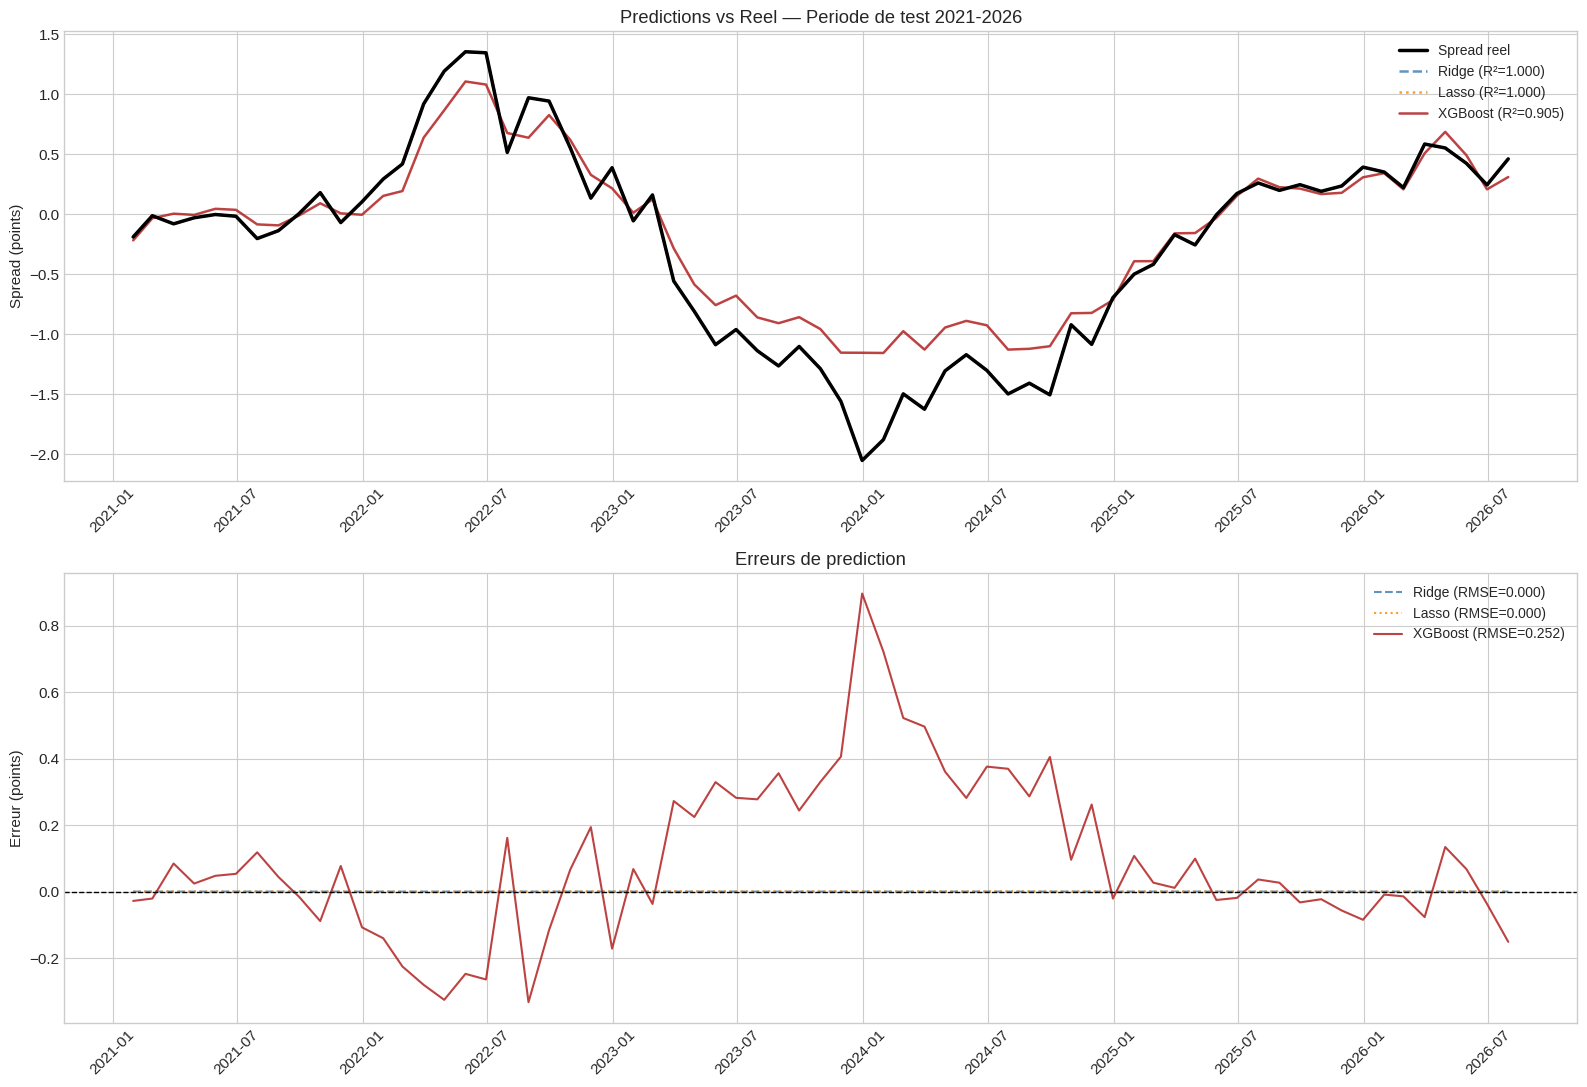

In [7]:
print('=' * 65)
print('  COMPARAISON — TEST 2021-2026')
print('=' * 65)
print(f'  {"Modele":<22} {"RMSE":>10} {"MAE":>10} {"R2":>8}')
print('-' * 65)
for name, r in results.items():
    print(f'  {name:<22} {r["rmse"]:>10.4f}  {r["mae"]:>10.4f}  {r["r2"]:>7.4f}')
print('=' * 65)

fig, axes = plt.subplots(2, 1, figsize=(16, 11))

ax = axes[0]
ax.plot(dates_test, y_test, color='black',
        linewidth=2.5, label='Spread reel', zorder=5)
colors = {'Ridge': 'steelblue', 'Lasso': 'darkorange', 'XGBoost': 'firebrick'}
styles = {'Ridge': '--', 'Lasso': ':', 'XGBoost': '-'}
for name, r in results.items():
    ax.plot(dates_test, r['y_pred'],
            color=colors[name], linewidth=1.8,
            linestyle=styles[name],
            label=f'{name} (R²={r["r2"]:.3f})', alpha=0.85)
ax.set_title('Predictions vs Reel — Periode de test 2021-2026')
ax.set_ylabel('Spread (points)')
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

ax = axes[1]
for name, r in results.items():
    errors = r['y_pred'] - y_test
    ax.plot(dates_test, errors,
            color=colors[name], linewidth=1.5,
            linestyle=styles[name],
            label=f'{name} (RMSE={r["rmse"]:.3f})', alpha=0.85)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Erreurs de prediction')
ax.set_ylabel('Erreur (points)')
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('figures/fig5_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Analyse SHAP — Interprétabilité

SHAP décompose chaque prédiction :
```
Spread prédit = E[Spread] + SHAP(Level) + SHAP(Slope) + ...
```
On analyse les drivers par régime pour répondre à la question
du tuteur : quels facteurs ont une relation structurelle stable ?

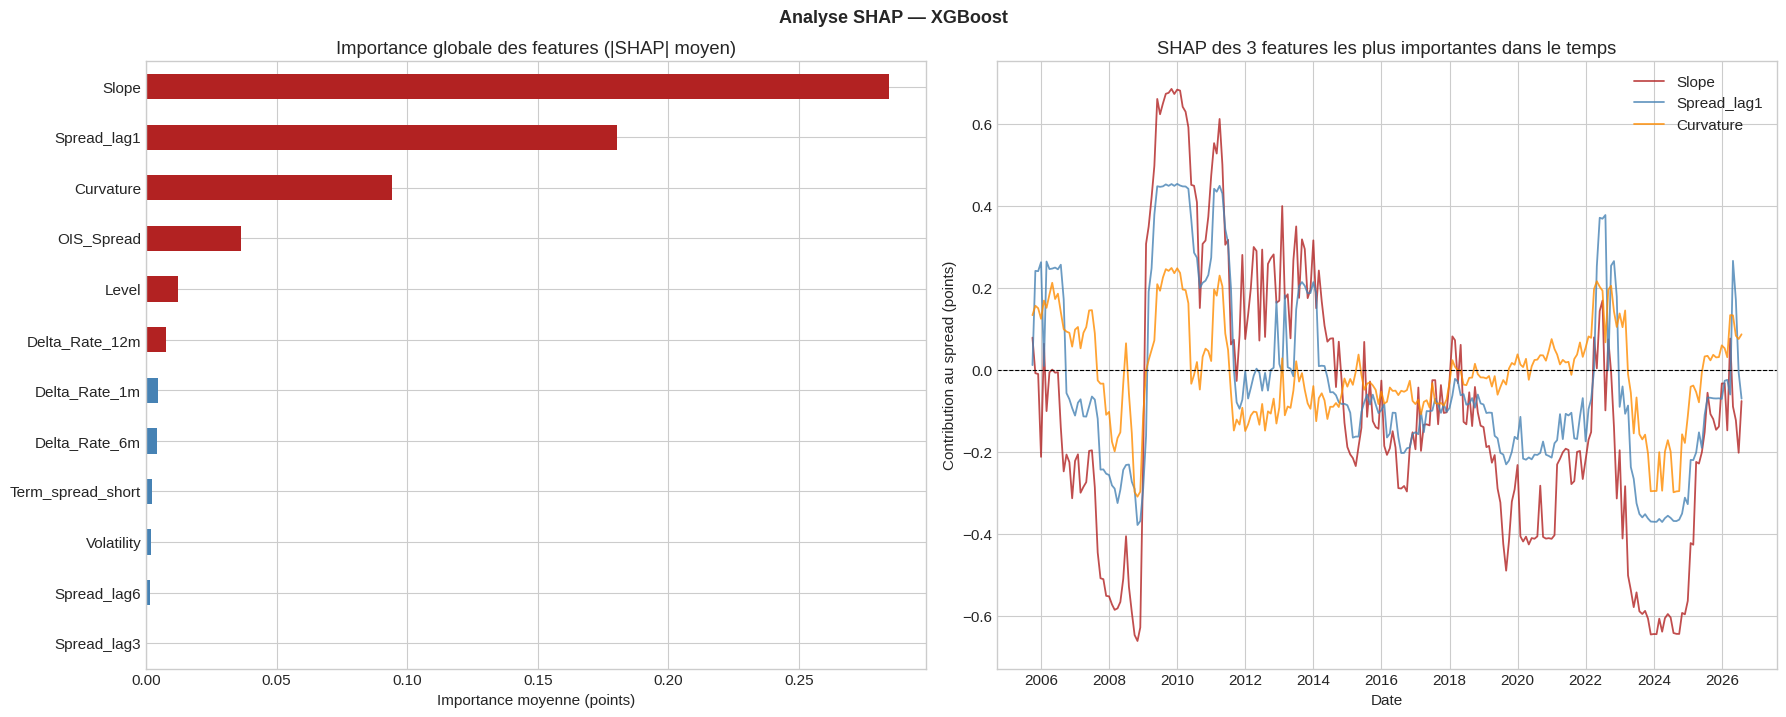

Top 3 features globalement :
  1. Slope : |SHAP| moyen = 0.2845
  2. Spread_lag1 : |SHAP| moyen = 0.1803
  3. Curvature : |SHAP| moyen = 0.0941


In [8]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)
shap_df     = pd.DataFrame(shap_values, columns=FEATURES, index=feat.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
mean_shap = np.abs(shap_df).mean().sort_values(ascending=True)
colors_bar = ['firebrick' if v > mean_shap.median() else 'steelblue'
              for v in mean_shap.values]
mean_shap.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Importance globale des features (|SHAP| moyen)')
ax.set_xlabel('Importance moyenne (points)')

ax = axes[1]
top3 = mean_shap.sort_values(ascending=False).head(3).index.tolist()
colors_t = ['firebrick', 'steelblue', 'darkorange']
for fname, color in zip(top3, colors_t):
    ax.plot(shap_df.index, shap_df[fname],
            label=fname, color=color, linewidth=1.3, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('SHAP des 3 features les plus importantes dans le temps')
ax.set_xlabel('Date')
ax.set_ylabel('Contribution au spread (points)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.suptitle('Analyse SHAP — XGBoost', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('figures/fig6_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 features globalement :')
for i, fname in enumerate(top3, 1):
    print(f'  {i}. {fname} : |SHAP| moyen = {mean_shap[fname]:.4f}')

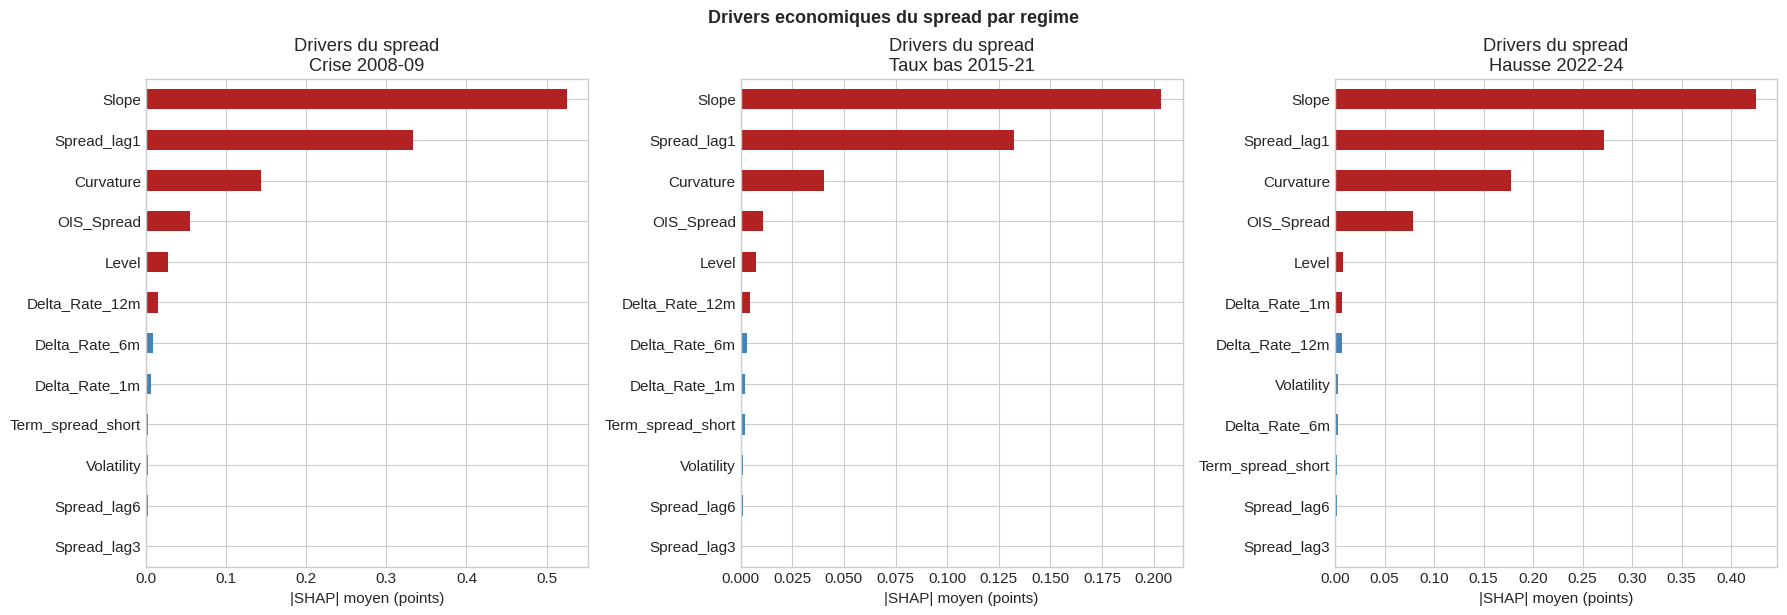

Driver principal par regime :
  Crise 2008-09             => Slope (0.5254)
  Taux bas 2015-21          => Slope (0.2037)
  Hausse 2022-24            => Slope (0.4252)


In [9]:
regimes = {
    'Crise 2008-09'    : ('2008-01', '2010-12'),
    'Taux bas 2015-21' : ('2015-01', '2020-12'),
    'Hausse 2022-24'   : ('2022-01', '2024-12'),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (regime_name, (start, end)) in zip(axes, regimes.items()):
    mask = (shap_df.index >= start) & (shap_df.index <= end)
    if mask.sum() == 0:
        ax.set_title(f'{regime_name}\n(pas de donnees)')
        continue
    regime_shap = np.abs(shap_df[mask]).mean().sort_values(ascending=True)
    colors_r = ['firebrick' if v > regime_shap.median() else 'steelblue'
                for v in regime_shap.values]
    regime_shap.plot(kind='barh', ax=ax, color=colors_r)
    ax.set_title(f'Drivers du spread\n{regime_name}')
    ax.set_xlabel('|SHAP| moyen (points)')

plt.tight_layout()
plt.suptitle('Drivers economiques du spread par regime',
             y=1.02, fontsize=13, fontweight='bold')
plt.savefig('figures/fig7_shap_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

print('Driver principal par regime :')
for regime_name, (start, end) in regimes.items():
    mask = (shap_df.index >= start) & (shap_df.index <= end)
    if mask.sum() == 0:
        continue
    top = np.abs(shap_df[mask]).mean().idxmax()
    val = np.abs(shap_df[mask]).mean().max()
    print(f'  {regime_name:<25} => {top} ({val:.4f})')

## 8. Résumé

In [10]:
print('=' * 65)
print('  RESUME CHAPITRE 5')
print('=' * 65)
print('\n  Note : Ridge et Lasso atteignent R²=1.0000 par une identite')
print('  algebrique exacte (Spread = 0.5*Slope + 0.5*Curvature), pas')
print('  par un veritable pouvoir predictif. Le modele de reference')
print('  retenu est donc XGBoost.')
print('\n  Performances sur test 2021-2026 :')
for name, r in results.items():
    print(f'    {name:<22} R²={r["r2"]:.4f}  RMSE={r["rmse"]:.4f}')
print('\n  Features les plus importantes (XGBoost, SHAP) :')
mean_shap = np.abs(shap_df).mean().sort_values(ascending=False)
for i, (fname, val) in enumerate(mean_shap.head(5).items(), 1):
    print(f'    {i}. {fname:<22} : {val:.4f}')
print('\n  Prochaine etape => Chapitre 6 : Agent LLM')
print('=' * 65)

  RESUME CHAPITRE 5

  Note : Ridge et Lasso atteignent R²=1.0000 par une identite
  algebrique exacte (Spread = 0.5*Slope + 0.5*Curvature), pas
  par un veritable pouvoir predictif. Le modele de reference
  retenu est donc XGBoost.

  Performances sur test 2021-2026 :
    Ridge                  R²=1.0000  RMSE=0.0000
    Lasso                  R²=1.0000  RMSE=0.0003
    XGBoost                R²=0.9052  RMSE=0.2524

  Features les plus importantes (XGBoost, SHAP) :
    1. Slope                  : 0.2845
    2. Spread_lag1            : 0.1803
    3. Curvature              : 0.0941
    4. OIS_Spread             : 0.0362
    5. Level                  : 0.0123

  Prochaine etape => Chapitre 6 : Agent LLM


In [12]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'shap', '-q'], capture_output=True)

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.interpolate import interp1d
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from io import StringIO
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
np.random.seed(42)
print('OK imports')

OK imports


# Stress Testing

In [13]:
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
np.random.seed(42)
print('OK imports')# Calibration Vasicek/Hull-White par MLE
rates_arr = (euribor / 100).values
dt = 1/12

def neg_ll(params, rates, dt):
    k, th, sig = params
    if k <= 0 or sig <= 0: return 1e10
    e1 = np.exp(-k*dt)
    e2 = np.exp(-2*k*dt)
    mu  = rates[:-1]*e1 + th*(1-e1)
    var = (sig**2/(2*k))*(1-e2)
    if np.any(var<=0): return 1e10
    return -np.sum(norm.logpdf(rates[1:], loc=mu, scale=np.sqrt(var)))

r_t, r_tm1 = rates_arr[1:], rates_arr[:-1]
b = np.cov(r_t, r_tm1)[0,1]/np.var(r_tm1)
a = r_t.mean() - b*r_tm1.mean()
k0   = max(-np.log(max(b,1e-6))/dt, 0.01)
th0  = a/(k0*dt) if k0>0 else r_t.mean()
sig0 = max((r_t - a - b*r_tm1).std()/np.sqrt(dt), 0.001)

res = minimize(neg_ll, [k0,th0,sig0], args=(rates_arr,dt),
               method='L-BFGS-B',
               bounds=[(1e-4,10),(-0.05,0.15),(1e-4,0.5)])
kappa_hw, _, sigma_hw = res.x

print(f'Hull-White calibre :')
print(f'  kappa = {kappa_hw:.4f}')
print(f'  sigma = {sigma_hw:.4f}')

# Courbe de taux actuelle pour theta(t)
mats_obs = np.array([1/12, 1, 2, 5, 10])
rates_obs = np.array([
    float(euribor.iloc[-1]/100),
    float(swap_1y.iloc[-1]/100),
    float(swap_2y.iloc[-1]/100),
    float(swap_5y.iloc[-1]/100),
    float(swap_10y.iloc[-1]/100),
])
curve = interp1d(mats_obs, rates_obs, kind='cubic', fill_value='extrapolate')
mats_fine = np.linspace(0.001, 10, 1000)
zero_fine = curve(mats_fine)
fwd_fine  = zero_fine + mats_fine * np.gradient(zero_fine, mats_fine)
print('Courbe forward calculee !')

OK imports
Hull-White calibre :
  kappa = 0.0556
  sigma = 0.0051
Courbe forward calculee !


## 4. Les 6 scénarios de chocs EBA

Les guidelines EBA (2022) imposent 6 scénarios standardisés :

| Scénario | Description |
|----------|-------------|
| Parallel Up | +200 bps sur toute la courbe |
| Parallel Down | -200 bps sur toute la courbe |
| Steepener | Court -100 bps, Long +100 bps |
| Flattener | Court +100 bps, Long -100 bps |
| Short Rate Up | +250 bps sur le court terme |
| Short Rate Down | -100 bps sur le court terme |

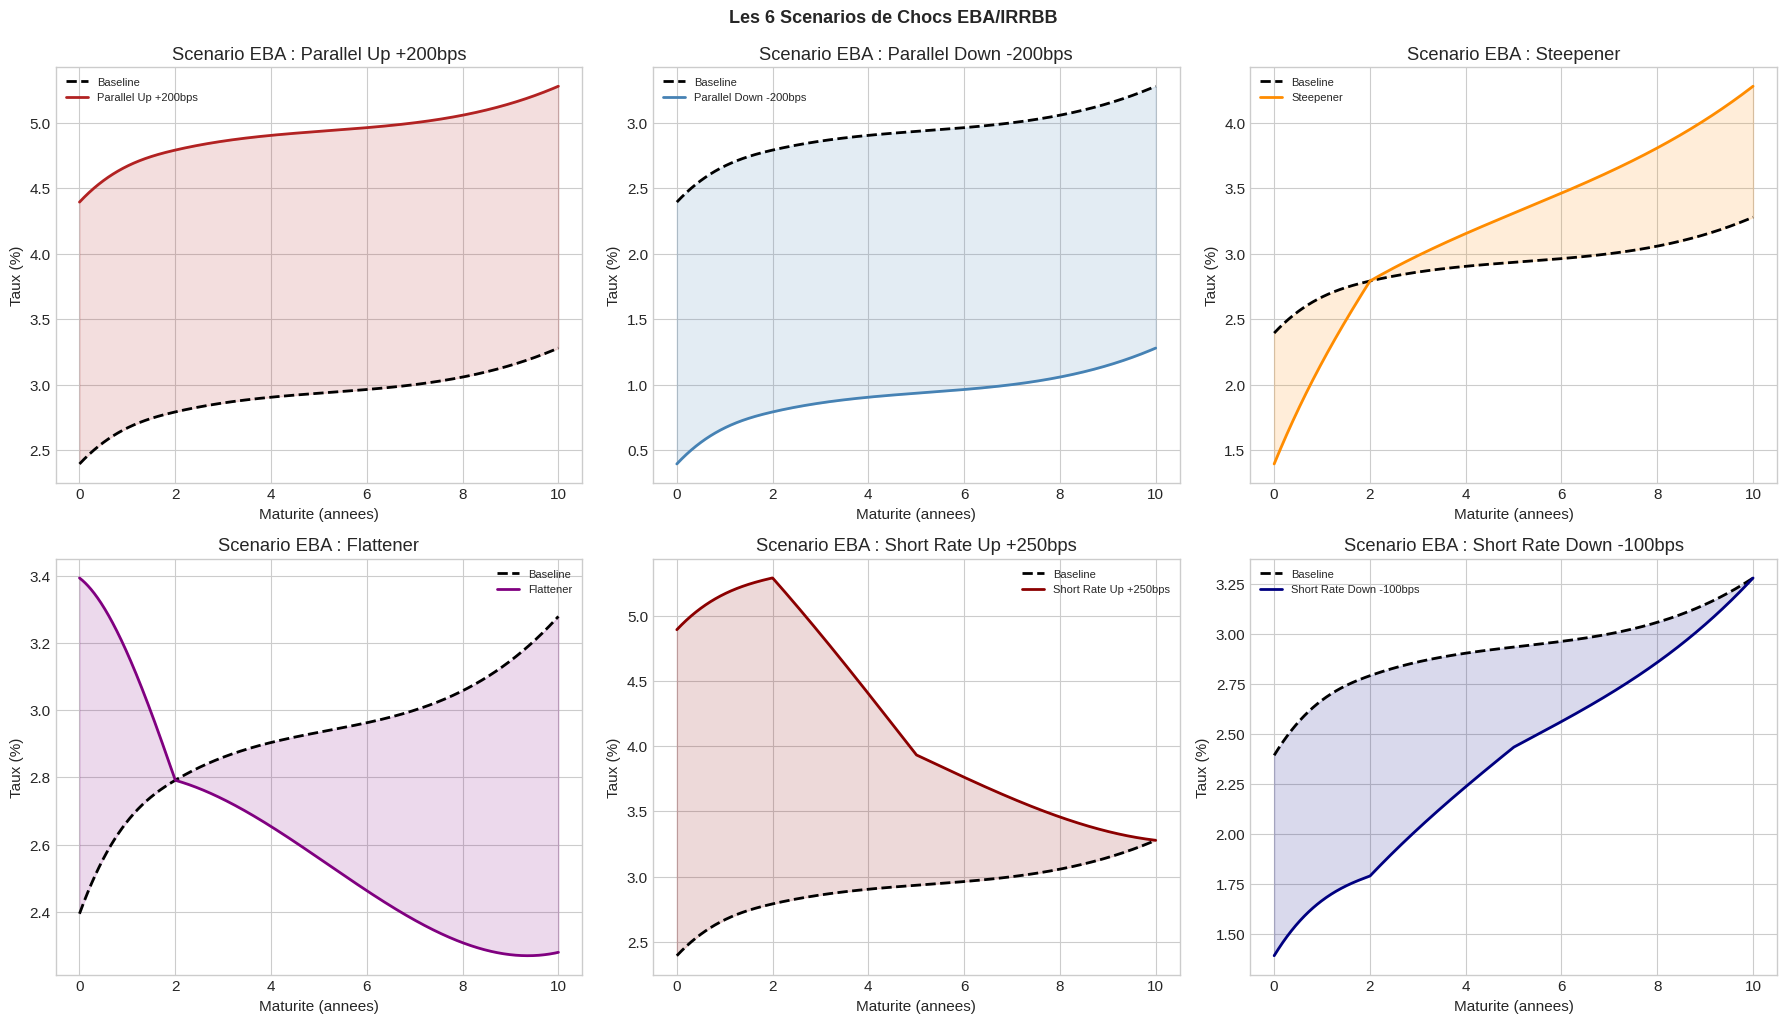

In [14]:
def apply_eba_shock(zero_rates, maturities, shock_type):
    shocked = zero_rates.copy()
    if shock_type == 'parallel_up':
        shocked += 0.02
    elif shock_type == 'parallel_down':
        shocked -= 0.02
    elif shock_type == 'steepener':
        shock = np.interp(maturities, [0,2,10], [-0.01,0,0.01])
        shocked += shock
    elif shock_type == 'flattener':
        shock = np.interp(maturities, [0,2,10], [0.01,0,-0.01])
        shocked += shock
    elif shock_type == 'short_up':
        shock = np.interp(maturities, [0,2,5,10], [0.025,0.025,0.01,0])
        shocked += shock
    elif shock_type == 'short_down':
        shock = np.interp(maturities, [0,2,5,10], [-0.01,-0.01,-0.005,0])
        shocked += shock
    return shocked

scenarios = [
    ('baseline',      'Baseline'),
    ('parallel_up',   'Parallel Up +200bps'),
    ('parallel_down', 'Parallel Down -200bps'),
    ('steepener',     'Steepener'),
    ('flattener',     'Flattener'),
    ('short_up',      'Short Rate Up +250bps'),
    ('short_down',    'Short Rate Down -100bps'),
]

# Visualisation des courbes choquees
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors_sc = ['firebrick','steelblue','darkorange','purple','darkred','navy']

for idx, (shock, label) in enumerate(scenarios[1:]):
    ax = axes[idx]
    z_shocked = apply_eba_shock(zero_fine, mats_fine, shock)
    ax.plot(mats_fine, zero_fine*100,
            'black', linewidth=2, linestyle='--', label='Baseline')
    ax.plot(mats_fine, z_shocked*100,
            color=colors_sc[idx], linewidth=2, label=label)
    ax.fill_between(mats_fine, zero_fine*100, z_shocked*100,
                    alpha=0.15, color=colors_sc[idx])
    ax.set_title(f'Scenario EBA : {label}')
    ax.set_xlabel('Maturite (annees)')
    ax.set_ylabel('Taux (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Les 6 Scenarios de Chocs EBA/IRRBB',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 5. Simulation Monte Carlo + Prédiction du Spread

Pour chaque scénario EBA :
1. On choque la courbe de taux
2. On calibre α(t) Hull-White sur la courbe choquée
3. On simule 5000 trajectoires de taux
4. Pour chaque trajectoire, on extrait les features
5. XGBoost prédit le spread pour chaque trajectoire
6. On calcule la distribution du spread → Spread-at-Risk

In [31]:
def build_features_from_trajectory(r_paths, swap_10y_scenario, swap_5y_scenario,
                                    swap_2y_scenario, euribor6_scenario):
    N_paths = r_paths.shape[1]

    # Le taux court reste stochastique (c'est le seul vrai facteur simule par HW)
    r_final = r_paths[-1, :] * 100
    r_start = r_paths[0, :] * 100

    swap10_pct = swap_10y_scenario * 100
    swap5_pct  = swap_5y_scenario  * 100
    swap2_pct  = swap_2y_scenario  * 100
    euribor6_pct = euribor6_scenario * 100

    # Memes formules exactes que le Chapitre 4 — plus de coefficients inventes
    level      = r_final
    slope      = swap10_pct - level
    curvature  = 2*swap5_pct - swap10_pct - level
    ois_spread = swap2_pct - level
    term_short = euribor6_pct - level

    # Volatilite : on garde la derniere valeur reelle connue (pas de bon moyen
    # de la projeter sous un scenario sans modele dedie — plus honnete que d'inventer)
    volatility = np.full(N_paths, float(feat['Volatility'].iloc[-1]))

    # Momentum : ecart entre le taux choque et le taux reel actuel aujourd'hui
    level_actuel = float(feat['Level'].iloc[-1])
    delta_1m  = np.full(N_paths, level.mean() - level_actuel)
    delta_6m  = np.full(N_paths, level.mean() - level_actuel)
    delta_12m = np.full(N_paths, level.mean() - level_actuel)

    spread_l1 = np.full(N_paths, float(feat['Spread'].iloc[-1]))
    spread_l3 = np.full(N_paths, float(feat['Spread'].iloc[-3]))
    spread_l6 = np.full(N_paths, float(feat['Spread'].iloc[-6]))

    X_sim = np.column_stack([
        level, slope, curvature, volatility,
        delta_1m, delta_6m, delta_12m,
        spread_l1, spread_l3, spread_l6,
        ois_spread, term_short
    ])
    return X_sim


def simulate_hw_spread(kappa, sigma, fwd_grid, r0, T, N_steps, N_paths, xgb_model,
                        swap_10y_scenario, swap_5y_scenario,
                        swap_2y_scenario, euribor6_scenario):
    dt_s   = T / N_steps
    t_grid = np.linspace(0, T, N_steps + 1)
    alpha = fwd_grid + (sigma**2/(2*kappa**2))*(1-np.exp(-kappa*t_grid))**2

    x_paths = np.zeros((N_steps+1, N_paths))
    x_paths[0,:] = r0 - alpha[0]
    e_kdt  = np.exp(-kappa*dt_s)
    std_ex = sigma*np.sqrt((1-np.exp(-2*kappa*dt_s))/(2*kappa))

    for i in range(N_steps):
        Z = np.random.standard_normal(N_paths)
        x_paths[i+1,:] = x_paths[i,:]*e_kdt + std_ex*Z

    r_paths = x_paths + alpha[:,np.newaxis]

    X_sim = build_features_from_trajectory(
        r_paths, swap_10y_scenario, swap_5y_scenario,
        swap_2y_scenario, euribor6_scenario
    )
    spread_sim = xgb_model.predict(X_sim)
    return spread_sim, r_paths


print('Fonctions redefinies avec les vraies formules du Chapitre 4')

Fonctions redefinies avec les vraies formules du Chapitre 4


In [32]:
# Cellule de simulation principale — ajoute swap5y_shocked
N_paths = 5000
T_sim   = 1
N_steps = 12
r0_sim  = float(euribor.iloc[-1]/100)

stress_results = {}

for shock, label in scenarios:
    z_sc = zero_fine.copy() if shock == 'baseline' else apply_eba_shock(zero_fine, mats_fine, shock)
    fwd_sc = z_sc + mats_fine * np.gradient(z_sc, mats_fine)
    r0_sc  = float(np.interp(0.001, mats_fine, z_sc))

    swap_10y_shocked = float(np.interp(10,  mats_fine, z_sc))
    swap_5y_shocked  = float(np.interp(5,   mats_fine, z_sc))
    swap_2y_shocked  = float(np.interp(2,   mats_fine, z_sc))
    euribor6_shocked = float(np.interp(0.5, mats_fine, z_sc))

    t_grid_sim   = np.linspace(0, T_sim, N_steps+1)
    fwd_grid_sim = np.interp(t_grid_sim, mats_fine, fwd_sc)

    spread_sim, r_sim = simulate_hw_spread(
        kappa_hw, sigma_hw, fwd_grid_sim, r0_sc, T_sim, N_steps, N_paths, xgb_model,
        swap_10y_shocked, swap_5y_shocked, swap_2y_shocked, euribor6_shocked
    )

    stress_results[label] = {
        'spread_sim': spread_sim, 'mean': spread_sim.mean(), 'std': spread_sim.std(),
        'sar_95': np.percentile(spread_sim, 5), 'sar_99': np.percentile(spread_sim, 1),
        'p95_up': np.percentile(spread_sim, 95), 'r_mean': r_sim[-1,:].mean(),
    }
    print(f'  {label:<30} Mean={spread_sim.mean():.3f}%  SaR95={np.percentile(spread_sim,5):.3f}%')

print('\nSimulation terminee !')

  Baseline                       Mean=0.134%  SaR95=-0.476%
  Parallel Up +200bps            Mean=0.043%  SaR95=-0.597%
  Parallel Down -200bps          Mean=0.188%  SaR95=-0.411%
  Steepener                      Mean=0.427%  SaR95=-0.064%
  Flattener                      Mean=-0.050%  SaR95=-0.353%
  Short Rate Up +250bps          Mean=-0.377%  SaR95=-0.829%
  Short Rate Down -100bps        Mean=0.545%  SaR95=-0.008%

Simulation terminee !


## 6. Spread-at-Risk et tableau de résultats

In [39]:
baseline_mean = stress_results['Baseline']['mean']

print('=' * 80)
print(f'  {"Scenario":<30} {"Spread moyen":>14} {"SaR 95%":>10} {"SaR 99%":>10} {"Delta vs BL":>12}')
print('=' * 80)

for label, r in stress_results.items():
    delta = (r['mean'] - baseline_mean) * 100
    flag  = ' ⚠️' if abs(delta) > 20 else ''
    print(f'  {label:<30} {r["mean"]*100:>13.3f}%  '
          f'{r["sar_95"]*100:>9.3f}%  '
          f'{r["sar_99"]*100:>9.3f}%  '
          f'{delta:>+11.1f}bps{flag}')

print('=' * 80)
print('\n⚠️ = scenario avec compression significative (>20bps vs baseline)')
print('SaR 95% : dans 95% des simulations le spread reste au-dessus de cette valeur')
print('SaR 99% : scenario de stress severe')

  Scenario                         Spread moyen    SaR 95%    SaR 99%  Delta vs BL
  Baseline                              13.436%    -47.609%    -59.170%         +0.0bps
  Parallel Up +200bps                    4.297%    -59.703%    -74.347%         -9.1bps
  Parallel Down -200bps                 18.803%    -41.081%    -54.309%         +5.4bps
  Steepener                             42.702%     -6.383%    -31.984%        +29.3bps ⚠️
  Flattener                             -5.009%    -35.298%    -53.650%        -18.4bps
  Short Rate Up +250bps                -37.698%    -82.946%    -87.818%        -51.1bps ⚠️
  Short Rate Down -100bps               54.473%     -0.766%    -15.772%        +41.0bps ⚠️

⚠️ = scenario avec compression significative (>20bps vs baseline)
SaR 95% : dans 95% des simulations le spread reste au-dessus de cette valeur
SaR 99% : scenario de stress severe


## 7. Visualisations

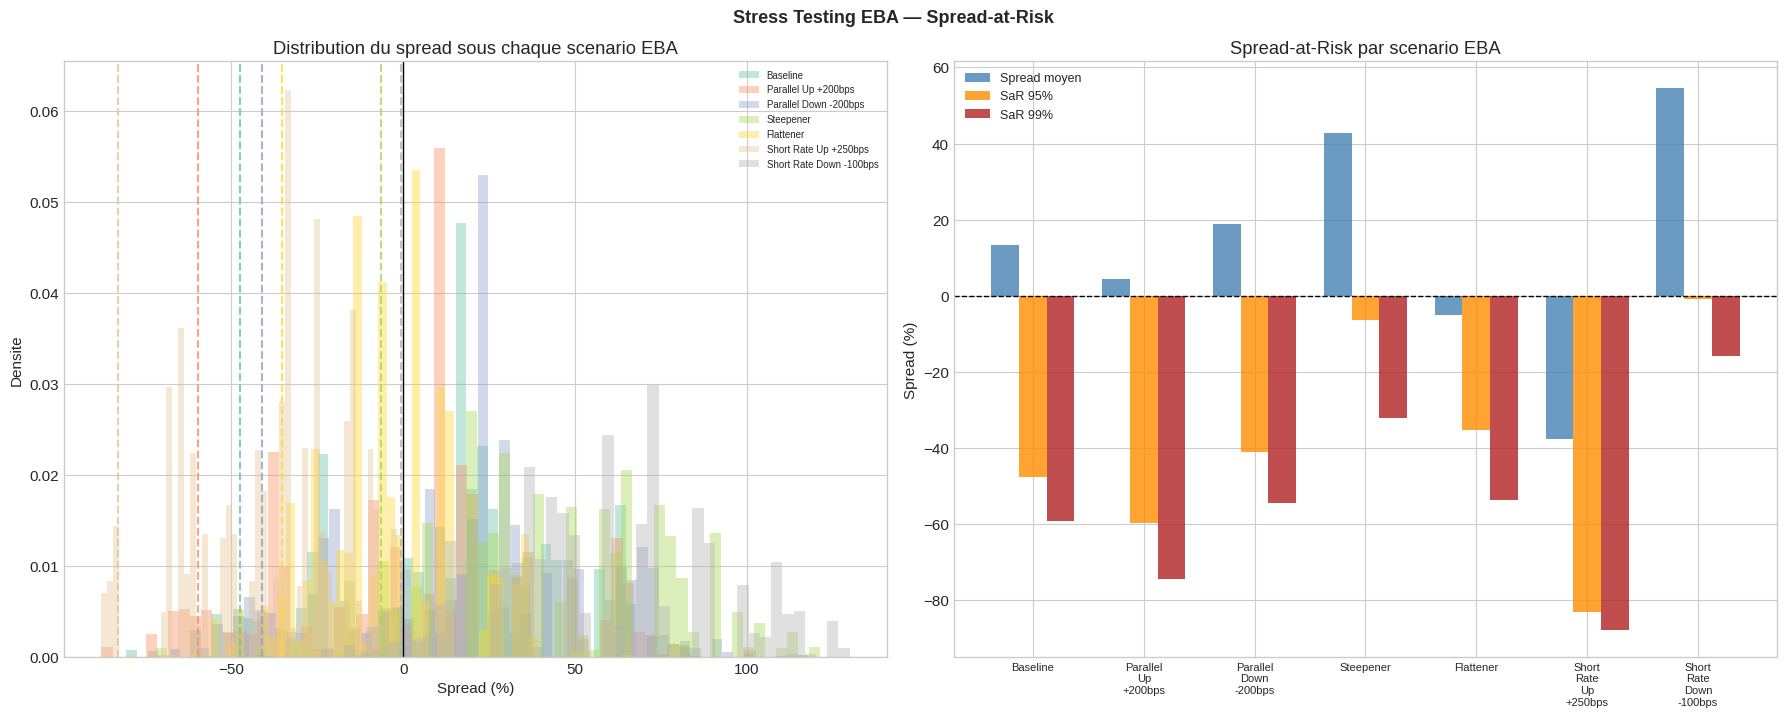

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graphique 1 : distributions du spread par scenario
ax = axes[0]
colors_plot = plt.cm.Set2(np.linspace(0, 1, len(stress_results)))
for (label, r), color in zip(stress_results.items(), colors_plot):
    ax.hist(r['spread_sim']*100, bins=60, density=True,
            alpha=0.4, label=label, color=color)
    ax.axvline(r['sar_95']*100, color=color,
               linewidth=1.5, linestyle='--', alpha=0.8)
ax.axvline(0, color='black', linewidth=1, linestyle='-')
ax.set_title('Distribution du spread sous chaque scenario EBA')
ax.set_xlabel('Spread (%)')
ax.set_ylabel('Densite')
ax.legend(fontsize=7, loc='upper right')

# Graphique 2 : Spread-at-Risk par scenario
ax = axes[1]
labels_plot = list(stress_results.keys())
sar95_vals  = [r['sar_95']*100 for r in stress_results.values()]
sar99_vals  = [r['sar_99']*100 for r in stress_results.values()]
means_vals  = [r['mean']*100   for r in stress_results.values()]

x = np.arange(len(labels_plot))
w = 0.25
ax.bar(x-w, means_vals,  w, label='Spread moyen', color='steelblue', alpha=0.8)
ax.bar(x,   sar95_vals,  w, label='SaR 95%',      color='darkorange', alpha=0.8)
ax.bar(x+w, sar99_vals,  w, label='SaR 99%',      color='firebrick', alpha=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([l.replace(' ', '\n') for l in labels_plot],
                   fontsize=8)
ax.set_title('Spread-at-Risk par scenario EBA')
ax.set_ylabel('Spread (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Stress Testing EBA — Spread-at-Risk',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 8. Sensibilité NIM et EVE

**NIM (Net Interest Margin)** = marge nette d'intérêt
Mesure l'impact sur la profitabilité courante.

**EVE (Economic Value of Equity)** = valeur économique des fonds propres
Mesure l'impact à long terme sur la valeur du bilan.

On approxime la sensibilité comme :
```
ΔNIM = Δspread × volume_actifs × durée_moyenne
ΔEVE = Δspread × duration_modifiée × volume_actifs

In [40]:
# Parametres ALM simplifies
volume_actifs    = 1.0    # normalise a 1
duree_moy_NIM    = 1.0    # 1 an (horizon NIM)
duration_EVE     = 4.0    # duration modifiee typique banking book

print('=' * 75)
print(f'  {"Scenario":<30} {"Spread moyen":>14} {"ΔNIM":>12} {"ΔEVE":>12}')
print('=' * 75)

baseline_spread = stress_results['Baseline']['mean']

nim_results = {}
eve_results = {}

for label, r in stress_results.items():
    delta_spread = r['mean'] - baseline_spread
    delta_nim    = delta_spread * volume_actifs * duree_moy_NIM
    delta_eve    = delta_spread * duration_EVE  * volume_actifs
    nim_results[label] = delta_nim
    eve_results[label] = delta_eve
    flag = ' ⚠️' if abs(delta_nim) > 0.10 else ''
    print(f'  {label:<30} {r["mean"]:>13.3f}%  '
          f'{delta_nim:>+11.3f}%  '
          f'{delta_eve:>+11.3f}%{flag}')

print('=' * 75)
print('\nDelta NIM/EVE = variation par rapport au scenario baseline')
print('⚠️ = impact NIM > 10 bps')

  Scenario                         Spread moyen         ΔNIM         ΔEVE
  Baseline                               0.134%       +0.000%       +0.000%
  Parallel Up +200bps                    0.043%       -0.091%       -0.366%
  Parallel Down -200bps                  0.188%       +0.054%       +0.215%
  Steepener                              0.427%       +0.293%       +1.171% ⚠️
  Flattener                             -0.050%       -0.184%       -0.738% ⚠️
  Short Rate Up +250bps                 -0.377%       -0.511%       -2.045% ⚠️
  Short Rate Down -100bps                0.545%       +0.410%       +1.641% ⚠️

Delta NIM/EVE = variation par rapport au scenario baseline
⚠️ = impact NIM > 10 bps


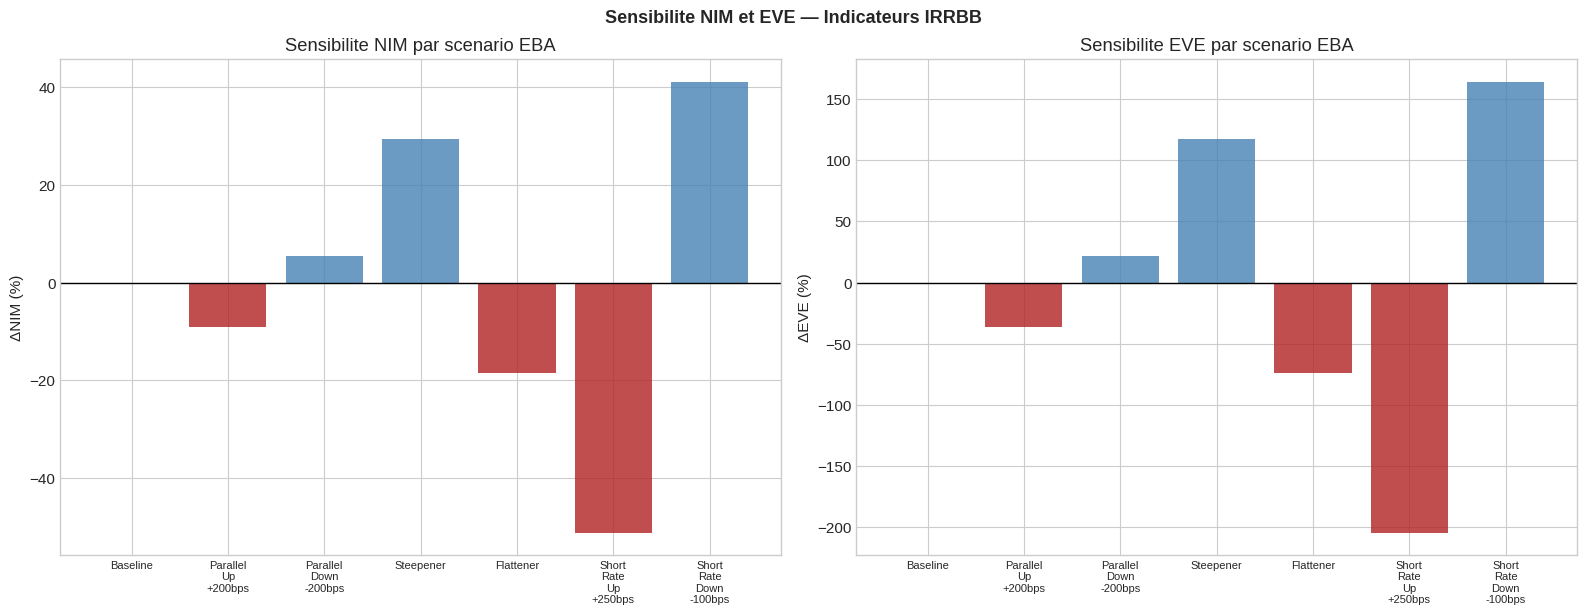

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels_plot = list(stress_results.keys())
nim_vals = [nim_results[l]*100 for l in labels_plot]
eve_vals = [eve_results[l]*100 for l in labels_plot]
x = np.arange(len(labels_plot))

ax = axes[0]
colors_bar = ['firebrick' if v < 0 else 'steelblue' for v in nim_vals]
ax.bar(x, nim_vals, color=colors_bar, alpha=0.8)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([l.replace(' ', '\n') for l in labels_plot], fontsize=8)
ax.set_title('Sensibilite NIM par scenario EBA')
ax.set_ylabel('ΔNIM (%)')

ax = axes[1]
colors_bar = ['firebrick' if v < 0 else 'steelblue' for v in eve_vals]
ax.bar(x, eve_vals, color=colors_bar, alpha=0.8)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([l.replace(' ', '\n') for l in labels_plot], fontsize=8)
ax.set_title('Sensibilite EVE par scenario EBA')
ax.set_ylabel('ΔEVE (%)')

plt.tight_layout()
plt.suptitle('Sensibilite NIM et EVE — Indicateurs IRRBB',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()